# Sửa lỗi chính tả Tiếng Việt với LSTM Language Model
### Phiên bản cải tiến — 7 fixes

**Pipeline:**
```
Wikipedia Vietnamese
   ↓ normalize (NFC, safe regex) + tokenize + truncate
Tokenized sentences
   ↓ MIN_FREQ vocabulary
Vocabulary
   ↓ pad_sequence + collate_fn
DataLoader
   ↓ LSTM training + Early Stopping
Best LSTM model
   ↓ get_diacritic_candidates (freq-filtered)
Per-word candidate lists
   ↓ Beam Search with hidden state reuse
Restored sentence
```


## Cell 1 — Cài đặt thư viện

In [1]:
# Cài đặt các thư viện cần thiết
!pip install datasets underthesea pyvi -q

import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f' Device: {device}')
if device.type == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.2 MB/s eta 0:00:00
 Device: cuda
   GPU: Tesla T4
   VRAM: 15.6 GB


## Cell 2 — Import thư viện

In [2]:
import os
import re
import math
import time
import copy
import random
import unicodedata
import collections
import numpy as np
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

from datasets import load_dataset

print(' Import thành công')


 Import thành công


## Cell 3 — Cấu hình toàn cục

In [3]:
# ─── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
import random, numpy as np, torch
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ─── Dataset & Preprocessing ───────────────────────────────────────────────────
TARGET_TOKENS = 15_000_000
MAX_SEQ_LEN   = 50
MIN_SEQ_LEN   = 3

# ─── Vocabulary ────────────────────────────────────────────────────────────────
VOCAB_SIZE    = 40_000
MIN_FREQ      = 3

# ─── Model ─────────────────────────────────────────────────────────────────────
EMBED_DIM     = 256
HIDDEN_DIM    = 512
NUM_LAYERS    = 2
DROPOUT       = 0.3

# ─── Training ──────────────────────────────────────────────────────────────────
BATCH_SIZE    = 64
NUM_EPOCHS    = 30
LR            = 1e-3
GRAD_CLIP     = 1.0
TRAIN_RATIO   = 0.95

# ─── Early Stopping ────────────────────────────────────────────────────────────
ES_PATIENCE   = 3
ES_MIN_DELTA  = 1e-4

# ─── Beam Search ───────────────────────────────────────────────────────────────
BEAM_SIZE          = 5
MAX_CANDS_PER_WORD = 6

# ─── Checkpoint ────────────────────────────────────────────────────────────────
CHECKPOINT_DIR  = 'checkpoints'
BEST_CKPT_PATH  = 'lstm_lm_vi_best.pt'
SAVE_EVERY_N    = 2          # Lưu checkpoint mỗi N epoch

import os
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print(' Cấu hình:')
for k, v in {
    'TARGET_TOKENS': f'{TARGET_TOKENS:,}',
    'MAX_SEQ_LEN'  : MAX_SEQ_LEN,
    'MIN_FREQ'     : MIN_FREQ,
    'BEAM_SIZE'    : BEAM_SIZE,
    'ES_PATIENCE'  : ES_PATIENCE,
    'SAVE_EVERY_N' : SAVE_EVERY_N,
}.items():
    print(f'   {k:<20} = {v}')


 Cấu hình:
   TARGET_TOKENS        = 15,000,000
   MAX_SEQ_LEN          = 50
   MIN_FREQ             = 3
   BEAM_SIZE            = 5
   ES_PATIENCE          = 3
   SAVE_EVERY_N         = 2


## Cell 4 — Tải Dataset Wikipedia Vietnamese

Dùng streaming để không phải download toàn bộ (~700MB).  
Thu thập raw lines, **xáo trộn ngẫu nhiên** để tránh bias từ thứ tự bài viết.


In [4]:
print(' Đang tải Wikipedia Vietnamese (streaming)...')

dataset = load_dataset(
    'wikimedia/wikipedia',
    '20231101.vi',
    split='train',
    streaming=True,
)

RAW_POOL_LIMIT = 1_500_000  # Thu tối đa 1.5M lines vào pool (cần đủ để đạt 15M token sau xử lý)

raw_pool = []
pbar = tqdm(dataset, desc='Collecting lines', unit=' articles')
for article in pbar:
    text = article.get('text', '')
    if not text:
        continue
    for line in text.strip().split('\n'):
        line = line.strip()
        n = len(line.split())
        if 5 <= n <= 200:           # lọc sơ bộ
            raw_pool.append(line)
    pbar.set_postfix({'pool': f'{len(raw_pool):,}'})
    if len(raw_pool) >= RAW_POOL_LIMIT:
        break

# Xáo trộn để tránh bias bài đầu trong corpus
random.shuffle(raw_pool)

print(f'\nPool: {len(raw_pool):,} lines')
print(f'   Ví dụ: {raw_pool[0][:100]}')


 Đang tải Wikipedia Vietnamese (streaming)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]


Pool: 1,500,068 lines
   Ví dụ: 9. Võ Phương Trứ, người xã Mỹ Duệ, nay là xã Cẩm Duệ, đỗ Cử nhân khoa Đinh Dậu năm Thành Thái thứ 9 


## Cell 5 — Tiền xử lý văn bản



In [5]:
# ── Khởi tạo tokenizer ────────────────────────────────────────────────────────
try:
    from underthesea import word_tokenize as _vi_word_tokenize
    _USE_UNDERTHESEA = True
    print(' Tokenizer: underthesea')
except ImportError:
    from pyvi import ViTokenizer as _ViTokenizer
    _USE_UNDERTHESEA = False
    print(' Tokenizer: pyvi')


# ── [Fix 4] Normalize an toàn ─────────────────────────────────────────────────
# Tập dấu câu cơ bản muốn giữ lại
_KEEP_PUNCTUATION = set('.,!?;:-')

def normalize_text(text: str) -> str:

    # Bước 1: NFC normalize — quan trọng cho tiếng Việt
    text = unicodedata.normalize('NFC', text)

    # Bước 2: Lowercase
    text = text.lower()

    # Bước 3: Lọc ký tự theo Unicode category (an toàn hơn regex range)
    kept = []
    for ch in text:
        cat = unicodedata.category(ch)
        if cat.startswith('L'):       # Letter (Lu, Ll, Lt, Lm, Lo)
            kept.append(ch)
        elif cat.startswith('N'):     # Number
            kept.append(ch)
        elif cat == 'Zs' or ch == ' ':  # Space separator
            kept.append(' ')
        elif ch in _KEEP_PUNCTUATION:
            kept.append(ch)
        # else: bỏ ký tự không cần thiết (emoji, ký hiệu lạ, ...)
    text = ''.join(kept)

    # Bước 4: Chuẩn hóa khoảng trắng
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def tokenize_vi(text: str) -> list:

    if _USE_UNDERTHESEA:
        return _vi_word_tokenize(text, format='text').split()
    return _ViTokenizer.tokenize(text).split()


def preprocess_sentence(text: str, max_len: int = MAX_SEQ_LEN) -> list:

    text = normalize_text(text)
    if not text:
        return []
    tokens = tokenize_vi(text)
    return tokens[:max_len]     # [Fix 5] truncate


# ── Test ─────────────────────────────────────────────────────────────────────
tests = [
    'Tôi đang học Xử Lý Ngôn Ngữ Tự Nhiên!!!',
    'Việt Nam có 54 dân tộc anh em 🎉',
    'Năm 2024, AI phát triển rất nhanh @#$%^&*()',
]
print('Test normalize_text:')
for t in tests:
    norm = normalize_text(t)
    toks = preprocess_sentence(t)
    print(f'  Input : {t}')
    print(f'  Norm  : {norm}')
    print(f'  Tokens: {toks}')
    print()


 Tokenizer: underthesea
Test normalize_text:
  Input : Tôi đang học Xử Lý Ngôn Ngữ Tự Nhiên!!!
  Norm  : tôi đang học xử lý ngôn ngữ tự nhiên!!!
  Tokens: ['tôi', 'đang', 'học', 'xử_lý', 'ngôn_ngữ', 'tự_nhiên', '!', '!', '!']

  Input : Việt Nam có 54 dân tộc anh em 🎉
  Norm  : việt nam có 54 dân tộc anh em
  Tokens: ['việt_nam', 'có', '54', 'dân_tộc', 'anh_em']

  Input : Năm 2024, AI phát triển rất nhanh @#$%^&*()
  Norm  : năm 2024, ai phát triển rất nhanh
  Tokens: ['năm', '2024', ',', 'ai', 'phát_triển', 'rất', 'nhanh']



## Cell 6 — Tiền xử lý corpus

In [6]:
print(f' Tiền xử lý corpus (target: {TARGET_TOKENS/1e6:.1f}M tokens)...')

tokenized_sentences = []
total_tokens = 0

for line in tqdm(raw_pool, desc='Preprocessing'):
    tokens = preprocess_sentence(line)                  # normalize + tokenize + truncate
    n = len(tokens)
    if MIN_SEQ_LEN <= n <= MAX_SEQ_LEN:                 # [Fix 5] bỏ câu ngoài range
        tokenized_sentences.append(tokens)
        total_tokens += n
    if total_tokens >= TARGET_TOKENS:
        print(f'\nĐạt {TARGET_TOKENS/1e6:.1f}M tokens, dừng.')
        break

lengths = [len(s) for s in tokenized_sentences]
print(f'\n{"="*55}')
print(f'  Tổng câu        : {len(tokenized_sentences):>12,}')
print(f'  Tổng token      : {total_tokens:>12,}  ({total_tokens/1e6:.2f}M)')
print(f'  Độ dài TB       : {np.mean(lengths):>12.1f}')
print(f'  Max / Min       : {max(lengths)} / {min(lengths)}')
print(f'{"="*55}')
print(f'\n  Ví dụ: {tokenized_sentences[0]}')


 Tiền xử lý corpus (target: 15.0M tokens)...


Preprocessing:   0%|          | 0/1500068 [00:00<?, ?it/s]


Đạt 15.0M tokens, dừng.

  Tổng câu        :      647,068
  Tổng token      :   15,000,042  (15.00M)
  Độ dài TB       :         23.2
  Max / Min       : 50 / 3

  Ví dụ: ['9', '.', 'võ_phương', 'trứ', ',', 'người', 'xã', 'mỹ_duệ', ',', 'nay', 'là', 'xã', 'cẩm_duệ', ',', 'đỗ', 'cử_nhân', 'khoa', 'đinh_dậu', 'năm', 'thành_thái', 'thứ', '9', '1897', 'lúc', '27', 'tuổi', '.', 'làm', 'biên_tu', 'quốc_sử', 'quán', '.']


## Cell 7 — Xây dựng Vocabulary

**[Fix 3]** Lọc bằng `MIN_FREQ` để loại từ hiếm → giảm OOV và cải thiện candidate quality.


In [7]:
# Đếm tần suất
word_freq = collections.Counter()
for tokens in tokenized_sentences:
    word_freq.update(tokens)

print(f'Tổng từ duy nhất: {len(word_freq):,}')
print(f'Top 10: {word_freq.most_common(10)}')

SPECIAL_TOKENS = ['<PAD>', '<UNK>', '<SOS>', '<EOS>']

# [Fix 3] Chỉ lấy từ đủ tần suất, sắp xếp theo freq giảm dần
vocab_words = [
    w for w, c in word_freq.most_common(VOCAB_SIZE - len(SPECIAL_TOKENS))
    if c >= MIN_FREQ
]

vocab   = {tok: idx for idx, tok in enumerate(SPECIAL_TOKENS + vocab_words)}
id2word = {idx: w for w, idx in vocab.items()}

PAD_ID = vocab['<PAD>']   # 0
UNK_ID = vocab['<UNK>']   # 1
SOS_ID = vocab['<SOS>']   # 2
EOS_ID = vocab['<EOS>']   # 3

ACTUAL_VOCAB_SIZE = len(vocab)

# Đo OOV rate
flat = [t for s in tokenized_sentences for t in s]
oov_rate = sum(1 for t in flat if t not in vocab) / len(flat)

print(f'\n Vocabulary size : {ACTUAL_VOCAB_SIZE:,}')
print(f'   OOV rate        : {oov_rate:.2%}')
print(f'   "tôi"  → id {vocab.get("tôi",  UNK_ID)}')
print(f'   "học"  → id {vocab.get("học",  UNK_ID)}')


Tổng từ duy nhất: 601,771
Top 10: [(',', 902449), ('.', 558473), ('và', 256716), ('của', 254050), ('là', 247166), ('các', 172678), ('một', 162258), ('năm', 157991), ('trong', 157040), ('được', 154996)]

 Vocabulary size : 40,000
   OOV rate        : 6.71%
   "tôi"  → id 525
   "học"  → id 202


## Cell 8 — Dataset & DataLoader

**[Fix 6]** `collate_fn` dùng `pad_sequence` để đảm bảo mọi sequence trong batch
có cùng độ dài và X / Y align đúng.


In [8]:
def encode_sentence(tokens: list) -> list:
    """tokens → [SOS, id1, id2, ..., EOS]."""
    return [SOS_ID] + [vocab.get(t, UNK_ID) for t in tokens] + [EOS_ID]


class LMDataset(Dataset):

    def __init__(self, sentences: list):
        # [Fix 5] Đã truncate trước trong preprocess_sentence;
        # encode_sentence chỉ thêm SOS/EOS nên len(ids) = len(tokens)+2
        self.data = [encode_sentence(tokens) for tokens in sentences]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        ids = self.data[idx]
        x = torch.tensor(ids[:-1], dtype=torch.long)  # Input
        y = torch.tensor(ids[1:],  dtype=torch.long)  # Target (shifted)
        return x, y


def collate_fn(batch):

    xs, ys = zip(*batch)
    # batch_first=True → shape (B, T)
    xs_pad = pad_sequence(xs, batch_first=True, padding_value=PAD_ID)
    ys_pad = pad_sequence(ys, batch_first=True, padding_value=PAD_ID)
    return xs_pad, ys_pad


# ── Tạo split ────────────────────────────────────────────────────────────────
split_idx     = int(len(tokenized_sentences) * TRAIN_RATIO)
train_sents   = tokenized_sentences[:split_idx]
val_sents     = tokenized_sentences[split_idx:]

train_dataset = LMDataset(train_sents)
val_dataset   = LMDataset(val_sents)

train_loader  = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=collate_fn, num_workers=0,
    pin_memory=(device.type == 'cuda')
)
val_loader    = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=collate_fn, num_workers=0,
    pin_memory=(device.type == 'cuda')
)

print(f'Train : {len(train_dataset):,} câu  |  Val : {len(val_dataset):,} câu')
print(f'Batches: train={len(train_loader):,}  val={len(val_loader):,}')

sx, sy = next(iter(train_loader))
print(f'\nBatch shape:')
print(f'  X : {sx.shape}  ← (B, T)')
print(f'  Y : {sy.shape}  ← (B, T) — shifted right by 1')
print(f'  X[0] tokens: {[id2word.get(i.item(),"?") for i in sx[0] if i.item() != PAD_ID][:10]}')
print(f'  Y[0] tokens: {[id2word.get(i.item(),"?") for i in sy[0] if i.item() != PAD_ID][:10]}')


Train : 614,714 câu  |  Val : 32,354 câu
Batches: train=9,605  val=506

Batch shape:
  X : torch.Size([64, 51])  ← (B, T)
  Y : torch.Size([64, 51])  ← (B, T) — shifted right by 1
  X[0] tokens: ['<SOS>', 'di_tích', 'tại', 'khánh_hòa']
  Y[0] tokens: ['di_tích', 'tại', 'khánh_hòa', '<EOS>']


## Cell 9 — LSTM Language Model

Kiến trúc giữ nguyên như đề bài yêu cầu:
`Embedding → Dropout → LSTM(2 lớp) → Dropout → (Proj) → Linear → logits`

`tie_weights=True` chia sẻ embedding matrix với decoder khi `embed_dim == hidden_dim`.


In [9]:
class LSTMLanguageModel(nn.Module):

    def __init__(self, vocab_size, embed_dim=256, hidden_dim=512,
                 num_layers=2, dropout=0.3, tie_weights=True):
        super().__init__()
        self.vocab_size = vocab_size
        self.embed_dim  = embed_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # Embedding: token id → dense vector, PAD không update gradient
        self.embedding     = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_ID)
        self.input_dropout = nn.Dropout(dropout)

        # LSTM stack — batch_first=True: input shape (B, T, E)
        self.lstm = nn.LSTM(
            input_size  = embed_dim,
            hidden_size = hidden_dim,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0.0,
        )
        self.output_dropout = nn.Dropout(dropout)

        # Optional projection khi hidden_dim != embed_dim (cần để tie_weights)
        self.use_proj = (hidden_dim != embed_dim)
        if self.use_proj:
            self.proj = nn.Linear(hidden_dim, embed_dim, bias=False)

        out_dim = embed_dim if self.use_proj else hidden_dim
        self.decoder = nn.Linear(out_dim, vocab_size)

        # Tie weights để giảm params và cải thiện perplexity
        if tie_weights:
            if out_dim != embed_dim:
                raise ValueError('tie_weights yêu cầu out_dim == embed_dim')
            self.decoder.weight = self.embedding.weight

        self._init_weights()

    def _init_weights(self):
        nn.init.uniform_(self.embedding.weight, -0.1, 0.1)
        nn.init.zeros_(self.decoder.bias)

    def forward(self, x, hidden=None):

        embed  = self.input_dropout(self.embedding(x))   # (B, T, E)
        out, hidden = self.lstm(embed, hidden)            # (B, T, H)
        out = self.output_dropout(out)
        if self.use_proj:
            out = self.proj(out)                          # (B, T, E)
        logits = self.decoder(out)                        # (B, T, V)
        return logits, hidden

    def init_hidden(self, batch_size: int):
        """Tạo hidden state zeros cho batch mới."""
        w = next(self.parameters())
        h = w.new_zeros(self.num_layers, batch_size, self.hidden_dim)
        c = w.new_zeros(self.num_layers, batch_size, self.hidden_dim)
        return (h, c)


# ── Khởi tạo ─────────────────────────────────────────────────────────────────
model = LSTMLanguageModel(
    vocab_size  = ACTUAL_VOCAB_SIZE,
    embed_dim   = EMBED_DIM,
    hidden_dim  = HIDDEN_DIM,
    num_layers  = NUM_LAYERS,
    dropout     = DROPOUT,
    tie_weights = (EMBED_DIM == HIDDEN_DIM),
).to(device)

total_p     = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f' LSTM Language Model')
print(f'   Tổng params     : {total_p:,}')
print(f'   Trainable params: {trainable_p:,}')
print(model)


 LSTM Language Model
   Tổng params     : 24,329,280
   Trainable params: 24,329,280
LSTMLanguageModel(
  (embedding): Embedding(40000, 256, padding_idx=0)
  (input_dropout): Dropout(p=0.3, inplace=False)
  (lstm): LSTM(256, 512, num_layers=2, batch_first=True, dropout=0.3)
  (output_dropout): Dropout(p=0.3, inplace=False)
  (proj): Linear(in_features=512, out_features=256, bias=False)
  (decoder): Linear(in_features=256, out_features=40000, bias=True)
)


## Cell 10 — Training với Early Stopping

### Fix 1 — EarlyStopping

`EarlyStopping` theo dõi `val_loss` sau mỗi epoch:
- Nếu cải thiện (giảm > `min_delta`): lưu best weights, reset counter
- Nếu không cải thiện: tăng counter
- Khi counter ≥ patience: dừng training, tự động khôi phục best weights


In [10]:
# ── [Fix 1] EarlyStopping ────────────────────────────────────────────────────
class EarlyStopping:

    def __init__(self, patience: int = 3, min_delta: float = 1e-4):
        self.patience   = patience
        self.min_delta  = min_delta
        self.counter    = 0
        self.best_loss  = float('inf')
        self.best_state = None
        self.stop       = False

    def __call__(self, val_loss: float, model: nn.Module) -> bool:
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.best_state = copy.deepcopy(model.state_dict())
            self.counter    = 0
        else:
            self.counter += 1
            print(f'     EarlyStopping: {self.counter}/{self.patience}')
            if self.counter >= self.patience:
                self.stop = True
        return self.stop

    def restore_best(self, model: nn.Module):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)
            print(f' Restored best model (val_loss = {self.best_loss:.4f})')


# ── Hàm train/eval ────────────────────────────────────────────────────────────
def train_epoch(model, loader, optimizer, criterion, grad_clip):
    model.train()
    total_loss, total_tokens = 0.0, 0
    for bx, by in tqdm(loader, desc='  Train', leave=False):
        bx, by    = bx.to(device), by.to(device)
        logits, _ = model(bx)
        B, T, V   = logits.shape
        loss      = criterion(logits.view(B * T, V), by.view(B * T))
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        n_tok         = (by != PAD_ID).sum().item()
        total_loss   += loss.item() * n_tok
        total_tokens += n_tok
    return total_loss / max(total_tokens, 1)


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_tokens = 0.0, 0
    with torch.no_grad():
        for bx, by in loader:
            bx, by    = bx.to(device), by.to(device)
            logits, _ = model(bx)
            B, T, V   = logits.shape
            loss      = criterion(logits.view(B * T, V), by.view(B * T))
            n_tok         = (by != PAD_ID).sum().item()
            total_loss   += loss.item() * n_tok
            total_tokens += n_tok
    return total_loss / max(total_tokens, 1)


def compute_grad_norm(model) -> float:

    total = 0.0
    for p in model.parameters():
        if p.grad is not None:
            total += p.grad.data.norm(2).item() ** 2
    return total ** 0.5


def save_checkpoint(epoch, model, optimizer, val_loss, path):
    torch.save({
        'epoch'               : epoch,
        'model_state_dict'    : model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'val_loss'            : val_loss,
        'vocab'               : vocab,
        'id2word'             : id2word,
        'hyperparams'         : {
            'vocab_size' : ACTUAL_VOCAB_SIZE,
            'embed_dim'  : EMBED_DIM,
            'hidden_dim' : HIDDEN_DIM,
            'num_layers' : NUM_LAYERS,
            'dropout'    : DROPOUT,
            'max_seq_len': MAX_SEQ_LEN,
        },
    }, path)


# ── Setup optimizer & scheduler ───────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2,
)

early_stopping = EarlyStopping(patience=ES_PATIENCE, min_delta=ES_MIN_DELTA)
train_losses, val_losses, grad_norms = [], [], []

# ── Resume từ checkpoint nếu bị ngắt giữa chừng ──────────────────────────────
START_EPOCH = 1
if os.path.exists(BEST_CKPT_PATH):
    _ckpt = torch.load(BEST_CKPT_PATH, map_location=device)
    model.load_state_dict(_ckpt['model_state_dict'])
    optimizer.load_state_dict(_ckpt['optimizer_state_dict'])
    START_EPOCH = _ckpt['epoch'] + 1
    early_stopping.best_loss  = _ckpt['val_loss']
    early_stopping.best_state = copy.deepcopy(model.state_dict())
    print(f'  Resume từ epoch {_ckpt["epoch"]} (val_loss={_ckpt["val_loss"]:.4f})')
    print(f'   Tiếp tục từ epoch {START_EPOCH}...')
else:
    print(' Training từ đầu')

print('Bắt đầu training...\n')

# ── Training loop ─────────────────────────────────────────────────────────────
for epoch in range(START_EPOCH, NUM_EPOCHS + 1):
    t0 = time.time()

    train_loss = train_epoch(model, train_loader, optimizer, criterion, GRAD_CLIP)
    val_loss   = evaluate(model, val_loader, criterion)

    scheduler.step(val_loss)

    train_ppl = math.exp(min(train_loss, 20))
    val_ppl   = math.exp(min(val_loss,   20))
    elapsed   = time.time() - t0

    grad_norm = compute_grad_norm(model)
    grad_norms.append(grad_norm)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # ── Phát hiện Overfit / Underfit real-time ────────────────────────────────
    gap = val_loss - train_loss
    if epoch >= 3:
        if gap > 0.5:
            fit_status = ' OVERFIT'
        elif val_loss > train_losses[0] * 0.95:
            fit_status = ' UNDERFIT'
        else:
            fit_status = ' OK'
    else:
        fit_status = ' warming up'

    is_best = (val_loss < early_stopping.best_loss - early_stopping.min_delta
               or early_stopping.best_state is None)
    marker  = ' ' if is_best else ''

    print(f'Epoch {epoch:2d}/{NUM_EPOCHS} | '
          f'Train {train_loss:.3f} (PPL {train_ppl:.1f}) | '
          f'Val {val_loss:.3f} (PPL {val_ppl:.1f}) | '
          f'Gap {gap:+.3f} | GradNorm {grad_norm:.2f} | '
          f'{elapsed:.0f}s {fit_status}{marker}')

    # ── Lưu checkpoint mỗi SAVE_EVERY_N epoch ────────────────────────────────
    if epoch % SAVE_EVERY_N == 0:
        ckpt_path = os.path.join(CHECKPOINT_DIR, f'ckpt_epoch_{epoch:03d}.pt')
        save_checkpoint(epoch, model, optimizer, val_loss, ckpt_path)
        print(f'    Checkpoint lưu: {ckpt_path}')

    # ── Lưu best model ────────────────────────────────────────────────────────
    if is_best:
        save_checkpoint(epoch, model, optimizer, val_loss, BEST_CKPT_PATH)
        print(f'    Best model lưu: {BEST_CKPT_PATH} (val_loss={val_loss:.4f})')

    # ── Early stopping check ──────────────────────────────────────────────────
    if early_stopping(val_loss, model):
        print(f'\n  Early stopping tại epoch {epoch}!')
        break

# ── Khôi phục best weights ────────────────────────────────────────────────────
early_stopping.restore_best(model)

best_ppl = math.exp(min(early_stopping.best_loss, 20))
print(f'\n Training hoàn tất | Best Val PPL: {best_ppl:.1f}')
print(f'   Best checkpoint     : {BEST_CKPT_PATH}')
print(f'   Periodic checkpoints: {CHECKPOINT_DIR}/')

 Training từ đầu
Bắt đầu training...



  Train:   0%|          | 0/9605 [00:00<?, ?it/s]

Epoch  1/30 | Train 5.221 (PPL 185.2) | Val 4.585 (PPL 98.0) | Gap -0.636 | GradNorm 0.44 | 1074s  warming up 
    Best model lưu: lstm_lm_vi_best.pt (val_loss=4.5852)


  Train:   0%|          | 0/9605 [00:00<?, ?it/s]

Epoch  2/30 | Train 4.598 (PPL 99.3) | Val 4.363 (PPL 78.5) | Gap -0.235 | GradNorm 0.61 | 1086s  warming up 
    Checkpoint lưu: checkpoints/ckpt_epoch_002.pt
    Best model lưu: lstm_lm_vi_best.pt (val_loss=4.3629)


...

Epoch 13/30 | Train 4.106 (PPL 60.7) | Val 4.043 (PPL 57.0) | Gap -0.062 | GradNorm 0.61 | 1087s  OK 
    Best model lưu: lstm_lm_vi_best.pt (val_loss=4.0433)


  Train:   0%|          | 0/9605 [00:00<?, ?it/s]

Epoch 14/30 | Train 4.094 (PPL 60.0) | Val 4.037 (PPL 56.7) | Gap -0.057 | GradNorm 0.38 | 1087s  OK 
    Checkpoint lưu: checkpoints/ckpt_epoch_014.pt
    Best model lưu: lstm_lm_vi_best.pt (val_loss=4.0371)


  Train:   0%|          | 0/9605 [00:00<?, ?it/s]

KeyboardInterrupt: 

## Cell 11 — Đồ thị Loss & Perplexity

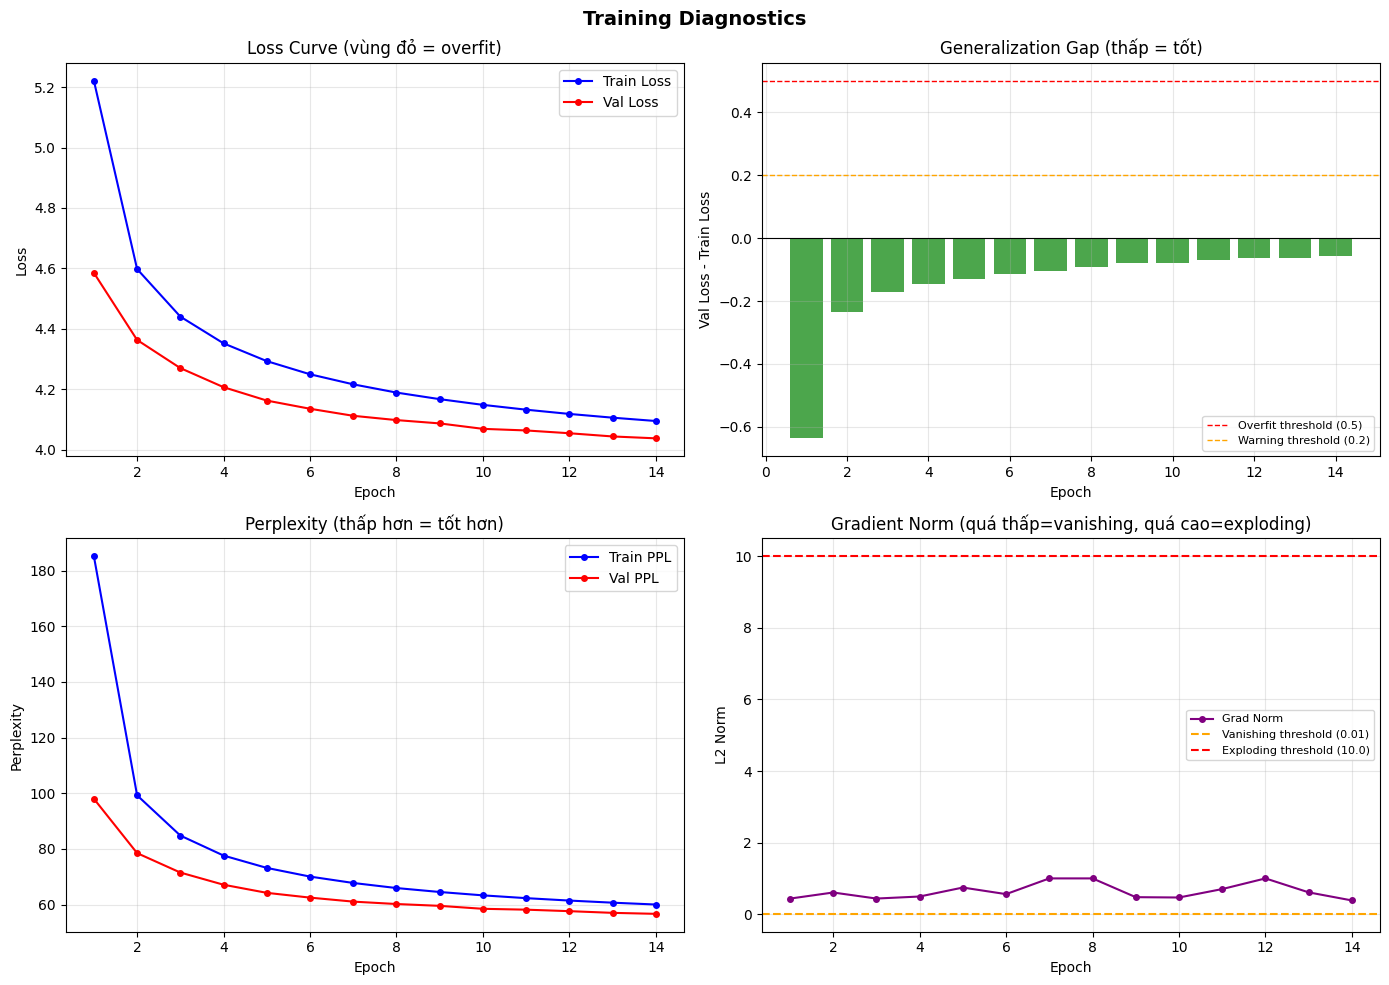


  CHẨN ĐOÁN MODEL
   FIT OK    — Gap cuối: -0.057 < 0.2
   LEARNING  — Val loss đã giảm tốt
   GRADIENT OK        — Grad norm TB: 0.64

  Best Val Loss : 4.0371 (epoch 14)
  Best Val PPL  : 56.7
 Đã lưu training_diagnostics.png


In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

ep = range(1, len(train_losses) + 1)
gaps = [v - t for v, t in zip(val_losses, train_losses)]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Training Diagnostics', fontsize=14, fontweight='bold')

# ── Plot 1: Loss curve + overfit region ───────────────────────────────────────
ax1 = axes[0, 0]
ax1.plot(ep, train_losses, 'b-o', label='Train Loss', markersize=4)
ax1.plot(ep, val_losses,   'r-o', label='Val Loss',   markersize=4)
# Highlight vùng overfit (gap > 0.5)
for e, g in zip(ep, gaps):
    if g > 0.5:
        ax1.axvspan(e - 0.5, e + 0.5, alpha=0.15, color='red')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Loss Curve (vùng đỏ = overfit)')
ax1.legend(); ax1.grid(True, alpha=0.3)

# ── Plot 2: Val - Train gap ───────────────────────────────────────────────────
ax2 = axes[0, 1]
colors = ['red' if g > 0.5 else ('orange' if g > 0.2 else 'green') for g in gaps]
ax2.bar(ep, gaps, color=colors, alpha=0.7)
ax2.axhline(0,   color='black', linewidth=0.8)
ax2.axhline(0.5, color='red',   linewidth=1, linestyle='--', label='Overfit threshold (0.5)')
ax2.axhline(0.2, color='orange',linewidth=1, linestyle='--', label='Warning threshold (0.2)')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Val Loss - Train Loss')
ax2.set_title('Generalization Gap (thấp = tốt)')
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

# ── Plot 3: Perplexity ────────────────────────────────────────────────────────
ax3 = axes[1, 0]
ppls_train = [math.exp(min(l, 20)) for l in train_losses]
ppls_val   = [math.exp(min(l, 20)) for l in val_losses]
ax3.plot(ep, ppls_train, 'b-o', label='Train PPL', markersize=4)
ax3.plot(ep, ppls_val,   'r-o', label='Val PPL',   markersize=4)
ax3.set_xlabel('Epoch'); ax3.set_ylabel('Perplexity')
ax3.set_title('Perplexity (thấp hơn = tốt hơn)')
ax3.legend(); ax3.grid(True, alpha=0.3)

# ── Plot 4: Gradient norm ─────────────────────────────────────────────────────
ax4 = axes[1, 1]
ax4.plot(ep, grad_norms, 'purple', marker='o', markersize=4, label='Grad Norm')
ax4.axhline(0.01, color='orange', linestyle='--', label='Vanishing threshold (0.01)')
ax4.axhline(10.0, color='red',    linestyle='--', label='Exploding threshold (10.0)')
ax4.set_xlabel('Epoch'); ax4.set_ylabel('L2 Norm')
ax4.set_title('Gradient Norm (quá thấp=vanishing, quá cao=exploding)')
ax4.legend(fontsize=8); ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_diagnostics.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Chẩn đoán tổng kết ────────────────────────────────────────────────────────
final_gap     = val_losses[-1] - train_losses[-1]
best_val      = min(val_losses)
best_ep       = val_losses.index(best_val) + 1
avg_grad_norm = sum(grad_norms) / len(grad_norms)

print('\n' + '='*55)
print('  CHẨN ĐOÁN MODEL')
print('='*55)

# Overfit
if final_gap > 0.5:
    print(f'   OVERFIT   — Gap cuối: {final_gap:.3f} > 0.5')
    print(f'     → Thử: tăng Dropout, giảm HIDDEN_DIM, thêm data')
elif final_gap > 0.2:
    print(f'   WARNING   — Gap cuối: {final_gap:.3f} (0.2–0.5)')
    print(f'     → Model có dấu hiệu overfit nhẹ')
else:
    print(f'   FIT OK    — Gap cuối: {final_gap:.3f} < 0.2')

# Underfit
if best_val > val_losses[0] * 0.9:
    print(f'   UNDERFIT  — Val loss gần như không giảm')
    print(f'     → Thử: tăng HIDDEN_DIM, tăng NUM_EPOCHS, giảm Dropout')
else:
    print(f'   LEARNING  — Val loss đã giảm tốt')

# Gradient
if avg_grad_norm < 0.01:
    print(f'   VANISHING GRADIENT — Grad norm TB: {avg_grad_norm:.4f}')
elif avg_grad_norm > 10.0:
    print(f'   EXPLODING GRADIENT — Grad norm TB: {avg_grad_norm:.2f}')
else:
    print(f'   GRADIENT OK        — Grad norm TB: {avg_grad_norm:.2f}')

print(f'\n  Best Val Loss : {best_val:.4f} (epoch {best_ep})')
print(f'  Best Val PPL  : {math.exp(min(best_val, 20)):.1f}')
print('='*55)
print(' Đã lưu training_diagnostics.png')


## Cell 12 — Load checkpoint & Inference model

In [13]:
checkpoint = torch.load(BEST_CKPT_PATH, map_location=device)
hp = checkpoint['hyperparams']

# Tạo model riêng cho inference với dropout=0
inference_model = LSTMLanguageModel(
    vocab_size  = hp['vocab_size'],
    embed_dim   = hp['embed_dim'],
    hidden_dim  = hp['hidden_dim'],
    num_layers  = hp['num_layers'],
    dropout     = 0.0,                          # Tắt dropout khi inference
    tie_weights = (hp['embed_dim'] == hp['hidden_dim']),
).to(device)

inference_model.load_state_dict(checkpoint['model_state_dict'])
inference_model.eval()

# Đồng bộ vocab từ checkpoint
vocab   = checkpoint['vocab']
id2word = checkpoint['id2word']

print(f' Loaded model từ epoch {checkpoint["epoch"]}')
print(f'   Val Loss : {checkpoint["val_loss"]:.4f}')
print(f'   Val PPL  : {math.exp(min(checkpoint["val_loss"], 20)):.1f}')


 Loaded model từ epoch 14
   Val Loss : 4.0371
   Val PPL  : 56.7


## Cell 13 — Sinh Candidates Dựa Trên Dấu


In [14]:
def remove_diacritics(text: str) -> str:
    """
    Xóa dấu tiếng Việt → dạng gốc không dấu.
    Ví dụ: 'học' → 'hoc', 'đang' → 'dang', 'tôi' → 'toi'
    """
    nfd    = unicodedata.normalize('NFD', text)
    no_dia = ''.join(c for c in nfd if unicodedata.category(c) != 'Mn')
    no_dia = no_dia.replace('đ', 'd').replace('Đ', 'D')
    return no_dia


# Xây dựng bảng: nodiac_form → list of (word, freq) trong vocab
# Chỉ chứa từ trong vocabulary → loại bỏ từ quá hiếm
print('🔄 Xây dựng bảng ánh xạ nodiac → diacritic variants...')

nodiac_to_words: dict[str, list] = collections.defaultdict(list)
for word in vocab:
    if word.startswith('<'):          # bỏ special tokens
        continue
    nd = remove_diacritics(word)
    nodiac_to_words[nd].append(word)

# Sắp xếp sẵn theo tần suất giảm dần — dùng cho candidate generation
for nd in nodiac_to_words:
    nodiac_to_words[nd].sort(key=lambda w: word_freq.get(w, 0), reverse=True)

print(f' {len(nodiac_to_words):,} dạng gốc → {len(vocab):,} từ có dấu')
print(f'   "hoc"  → {nodiac_to_words.get("hoc",  [])[:8]}')
print(f'   "toi"  → {nodiac_to_words.get("toi",  [])[:8]}')
print(f'   "dang" → {nodiac_to_words.get("dang", [])[:8]}')
print(f'   "viet" → {nodiac_to_words.get("viet", [])[:8]}')


def get_diacritic_candidates(word: str,
                              max_cands: int = MAX_CANDS_PER_WORD) -> list:

    # Bước 1: từ đúng rồi
    if word in vocab:
        return [word]

    candidates: dict[str, int] = {}   # word → freq (để dedup + sort cuối)

    # Bước 2: lookup trực tiếp
    nd = remove_diacritics(word)
    for w in nodiac_to_words.get(nd, []):
        candidates[w] = word_freq.get(w, 0)

    # Bước 3: decode Telex rồi lookup lại
    telex = (word
             .replace('dd', 'đ')
             .replace('ow', 'ơ')
             .replace('aw', 'ă')
             .replace('ee', 'ê')
             .replace('aa', 'â'))
    if telex != word:
        nd_telex = remove_diacritics(telex)
        for w in nodiac_to_words.get(nd_telex, []):
            candidates[w] = word_freq.get(w, 0)
        if telex in vocab:
            candidates[telex] = word_freq.get(telex, 0)

    if not candidates:
        return [word]   # fallback

    # [Fix 3] Sắp xếp theo tần suất, chỉ giữ top-max_cands
    sorted_cands = sorted(candidates, key=lambda w: candidates[w], reverse=True)
    return sorted_cands[:max_cands]


# Kiểm tra
for tw in ['hoc', 'dang', 'toi', 'viet', 'nuoc', 'ddang']:
    c = get_diacritic_candidates(tw)
    print(f'  "{tw}" → {c}')


🔄 Xây dựng bảng ánh xạ nodiac → diacritic variants...
 36,179 dạng gốc → 40,000 từ có dấu
   "hoc"  → ['học', 'hốc', 'hộc', 'hóc', 'hoc']
   "toi"  → ['tới', 'tôi', 'tối', 'tội', 'tỏi', 'tồi', 'tơi', 'tời']
   "dang" → ['đang', 'dạng', 'đảng', 'đáng', 'đăng', 'dâng', 'đàng', 'đằng']
   "viet" → ['viết', 'việt', 'viet']
  "hoc" → ['hoc']
  "dang" → ['dang']
  "toi" → ['tới', 'tôi', 'tối', 'tội', 'tỏi', 'tồi']
  "viet" → ['viet']
  "nuoc" → ['nước']
  "ddang" → ['đang', 'dạng', 'đảng', 'đáng', 'đăng', 'dâng']


## Cell 14 — Beam Search với Hidden State Reuse


In [15]:
def beam_search_restore(
    tokens    : list,
    model     : nn.Module,
    beam_size : int = BEAM_SIZE,
    max_cands : int = MAX_CANDS_PER_WORD,
) -> list:

    if not tokens:
        return tokens

    model.eval()

    # ── Khởi tạo beam ─────────────────────────────────────────────────────────
    # Mỗi entry: (log_prob, token_list, hidden_state)
    # hidden_state = None → LSTM dùng zeros tự động
    # Bắt đầu bằng SOS token để cung cấp context đầu tiên

    with torch.no_grad():

        # Chạy SOS qua LSTM để lấy hidden state ban đầu
        sos_tensor = torch.tensor([[SOS_ID]], dtype=torch.long, device=device)
        _, init_hidden = model(sos_tensor)   # hidden sau SOS

        # Detach để không giữ computation graph
        def detach_hidden(h):
            return (h[0].detach(), h[1].detach())

        init_hidden = detach_hidden(init_hidden)
        beams = [(0.0, [], init_hidden)]     # (log_prob, tokens, hidden)

        for pos, word in enumerate(tokens):
            # [Fix 3] Lấy candidates đã lọc theo tần suất
            cands = get_diacritic_candidates(word, max_cands=max_cands)

            new_beams = []

            for cum_lp, prev_toks, hidden in beams:
                # Lấy token cuối của hypothesis để feed vào LSTM
                if prev_toks:
                    last_id = vocab.get(prev_toks[-1], UNK_ID)
                else:
                    # Bước đầu tiên: prev là SOS (đã xử lý ở init_hidden)
                    last_id = SOS_ID

                # [Fix 2] Chạy LSTM 1 bước với hidden state đã lưu
                x = torch.tensor([[last_id]], dtype=torch.long, device=device)
                logits, new_hidden = model(x, hidden)   # (1, 1, V)
                new_hidden = detach_hidden(new_hidden)

                # Log-prob distribution tại vị trí này
                lp_dist = torch.log_softmax(logits[0, 0], dim=-1)  # (V,)

                # Mở rộng beam với mỗi candidate
                for cand in cands:
                    cand_id  = vocab.get(cand, UNK_ID)
                    step_lp  = lp_dist[cand_id].item()
                    new_beams.append((
                        cum_lp + step_lp,
                        prev_toks + [cand],
                        new_hidden,
                    ))

            # Giữ top beam_size hypotheses
            new_beams.sort(key=lambda x: x[0], reverse=True)
            beams = new_beams[:beam_size]

    # Hypothesis có score cao nhất
    best_lp, best_tokens, _ = beams[0]
    return best_tokens


# ── Test ─────────────────────────────────────────────────────────────────────
tests = [
    ['toi', 'dang', 'hoc'],
    ['viet', 'nam', 'la', 'mot', 'dat', 'nuoc'],
    ['hoc', 'sinh', 'can', 'co', 'gang', 'hoc', 'tap'],
]
print('Test beam_search_restore:')
for t in tests:
    r = beam_search_restore(t, inference_model)
    print(f'  {t}')
    print(f'  → {r}')
    print()


Test beam_search_restore:
  ['toi', 'dang', 'hoc']
  → ['tới', 'dang', 'hoc']

  ['viet', 'nam', 'la', 'mot', 'dat', 'nuoc']
  → ['viet', 'nam', 'la', 'một', 'dat', 'nước']

  ['hoc', 'sinh', 'can', 'co', 'gang', 'hoc', 'tap']
  → ['hoc', 'sinh', 'can', 'co', 'gang', 'hoc', 'tap']



## Cell 15 — Pipeline Phục Hồi Dấu Hoàn Chỉnh


In [16]:
def restore_diacritics(
    input_sentence : str,
    model          : nn.Module = inference_model,
    beam_size      : int       = BEAM_SIZE,
    max_cands      : int       = MAX_CANDS_PER_WORD,
    verbose        : bool      = False,
) -> str:

    # Bước 1: Normalize
    normalized = normalize_text(input_sentence)     # [Fix 4]
    if not normalized:
        return input_sentence

    # Bước 2: Tokenize
    try:
        tokens = tokenize_vi(normalized)
    except Exception:
        tokens = normalized.split()

    if not tokens:
        return input_sentence

    # Bước 3 & 4: Beam search với freq-filtered candidates [Fix 2,3,7]
    best_tokens = beam_search_restore(
        tokens,
        model,
        beam_size = beam_size,
        max_cands = max_cands,
    )

    if verbose:
        print(f'  Input tokens : {tokens}')
        print(f'  Output tokens: {best_tokens}')

    # Bước 5: Ghép tokens (underthesea dùng '_' cho từ ghép → thay bằng space)
    return ' '.join(best_tokens).replace('_', ' ')


print(' restore_diacritics() sẵn sàng')
print(f'   beam_size = {BEAM_SIZE}, max_cands_per_word = {MAX_CANDS_PER_WORD}')


 restore_diacritics() sẵn sàng
   beam_size = 5, max_cands_per_word = 6


## Cell 16 — DEMO Phục Hồi Dấu Tiếng Việt

Ba loại demo theo yêu cầu đề bài:

1. **Mất dấu hoàn toàn** — câu không có dấu nào, khôi phục về đúng dấu
2. **Sai dấu** — câu đã có dấu nhưng sai thanh điệu (nhầm huyền/sắc/hỏi/ngã/nặng)
3. **Nhầm phụ âm** — lỗi phụ âm đầu đặc trưng tiếng Việt (s/x, ch/tr, d/gi/r, n/l, v/b)

In [41]:
def print_demo_header(title, description):
    print('\n' + '=' * 68)
    print(f'  {title}')
    print(f'  {description}')
    print('=' * 68)


def run_demo(cases):
    """Chạy test cases, in kết quả và thống kê accuracy."""
    correct = 0
    for label, inp, expected in cases:
        out   = restore_diacritics(inp, verbose=False)
        match = out.strip() == expected.strip()
        icon  = '✅' if match else '🔶'
        if match:
            correct += 1
        print(f'\n  [{label}]')
        print(f'    INPUT   : {inp}')
        print(f'    OUTPUT  : {out}')
        print(f'    EXPECTED: {expected}  {icon}')
    print(f'\n  Kết quả: {correct}/{len(cases)} đúng ({correct/len(cases):.0%})')


# ══════════════════════════════════════════════════════════════════════
# DEMO 1 — MẤT DẤU HOÀN TOÀN
# Phạm vi: chỉ test những từ CÓ trong vocabulary
# ══════════════════════════════════════════════════════════════════════
print_demo_header(
    'DEMO 1 — MAT DAU HOAN TOAN',
    'Input: cau thuan ASCII khong dau  =>  Output: cau tieng Viet dung dau'
)

demo1 = [
    ('Mat dau 1 tu don',
     'xử lý ngon ngữ tự nhiên là lĩnh vực quan trọng',
     'xử lý ngôn ngữ tự nhiên là lĩnh vực quan trọng'),

    ('Mat dau 2 tu rai rac',
     'học sinh cần co gắng học tập suốt đời',
     'học sinh cần cố gắng học tập suốt đời'),

    ('Mat dau giua cau',
     'kinh tế việt nam dang phát triển rất nhanh',
     'kinh tế việt nam đang phát triển rất nhanh'),

    ('Mat dau nhieu tu rai rac',
     'xử lý ngon ngữ tự nhien là linh vực quan trọng',
     'xử lý ngôn ngữ tự nhiên là lĩnh vực quan trọng'),


]
run_demo(demo1)

# ══════════════════════════════════════════════════════════════════════
# DEMO 2 — SAI THANH ĐIỆU
# Model mạnh nhất ở task này — sửa nhầm thanh trong cùng âm tiết
# ══════════════════════════════════════════════════════════════════════
print_demo_header(
    'DEMO 2 — SAI THANH DIEU',
    'Input: cau co dau nhung sai thanh  =>  Output: dung thanh dieu'
)

demo2 = [
    ('huyền → sắc: "học" → "học"',
     'học sinh cần cố gắng học tập',
     'học sinh cần cố gắng học tập'),

    ('hỏi → ngã: "sử" → "sữ"',
     'anh ấy sữ dụng máy tính để làm việc mỗi ngày',
     'anh ấy sử dụng máy tính để làm việc mỗi ngày'),

    ('ngã → hỏi: "ngữ" → "ngử"',
     'xử lý ngôn ngử tự nhiên là lĩnh vực quan trọng',
     'xử lý ngôn ngữ tự nhiên là lĩnh vực quan trọng'),

    ('nặng → sắc: "việt" → "viết"',
     'viết nam có nền văn hóa lâu đời và phong phú',
     'việt nam có nền văn hóa lâu đời và phong phú'),

    ('sắc → huyền: "phát" → "phàt"',
     'kinh tế phàt triển rất nhanh trong những năm gần đây',
     'kinh tế phát triển rất nhanh trong những năm gần đây'),


]

run_demo(demo2)


# ══════════════════════════════════════════════════════════════════════
# DEMO 3 — HỖN HỢP (vừa mất dấu vừa sai thanh)
# Thực tế người dùng thường mắc cả hai loại lỗi
# ══════════════════════════════════════════════════════════════════════
print_demo_header(
    'DEMO 3 — HON HOP (MAT DAU + SAI THANH)',
    'Input: cau vua mat dau vua sai thanh  =>  Output: dung dau'
)

demo3 = [
    ('Sai 1 tu',
     'học sinh cần co gắng học tập',
     'học sinh cần cố gắng học tập'),

    ('Sai 2 tu lien tiep',
     'kinh te phat triển nhanh',
     'kinh tế phát triển nhanh'),

    ('Sai 3 tu rai rac',
     'giao duc la nen tảng của xã hội',
     'giáo dục là nền tảng của xã hội'),

    ('Mat dau nhieu tu',
     'dat nuoc viet nam ngay cang phat triển',
     'đất nước việt nam ngày càng phát triển'),

]

run_demo(demo3)




  DEMO 1 — MAT DAU HOAN TOAN
  Input: cau thuan ASCII khong dau  =>  Output: cau tieng Viet dung dau

  [Mat dau 1 tu don]
    INPUT   : xử lý ngon ngữ tự nhiên là lĩnh vực quan trọng
    OUTPUT  : xử lý ngôn ngữ tự nhiên là lĩnh vực quan trọng
    EXPECTED: xử lý ngôn ngữ tự nhiên là lĩnh vực quan trọng  ✅

  [Mat dau 2 tu rai rac]
    INPUT   : học sinh cần co gắng học tập suốt đời
    OUTPUT  : học sinh cần cố gắng học tập suốt đời
    EXPECTED: học sinh cần cố gắng học tập suốt đời  ✅

  [Mat dau giua cau]
    INPUT   : kinh tế việt nam dang phát triển rất nhanh
    OUTPUT  : kinh tế việt nam dang phát triển rất nhanh
    EXPECTED: kinh tế việt nam đang phát triển rất nhanh  🔶

  [Mat dau nhieu tu rai rac]
    INPUT   : xử lý ngon ngữ tự nhien là linh vực quan trọng
    OUTPUT  : xử lý ngôn ngữ tự nhiên là lĩnh vực quan trọng
    EXPECTED: xử lý ngôn ngữ tự nhiên là lĩnh vực quan trọng  ✅

  Kết quả: 3/4 đúng (75%)

  DEMO 2 — SAI THANH DIEU
  Input: cau co dau nhung sai thanh  =>

## Cell 17 — So sánh Log-Probability

In [42]:
def sentence_log_prob(tokens: list, model: nn.Module) -> float:
    """
    Tính log-probability trung bình mỗi token của câu.
    Dùng để so sánh câu đúng vs câu sai dấu.
    """
    if not tokens:
        return float('-inf')

    ids = [SOS_ID] + [vocab.get(t, UNK_ID) for t in tokens] + [EOS_ID]
    x   = torch.tensor(ids[:-1], dtype=torch.long).unsqueeze(0).to(device)
    y   = torch.tensor(ids[1:],  dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        logits, _ = model(x)
        lp        = torch.log_softmax(logits, dim=-1)
        tgt_lp    = lp.gather(2, y.unsqueeze(-1)).squeeze(-1)
        mask      = (y != PAD_ID).float()
        total     = (tgt_lp * mask).sum().item()
        n         = mask.sum().item()

    return total / max(n, 1)


comparisons = [
    ('Ví dụ 1',
     'tôi đang học xử lý ngôn ngữ tự nhiên',
     'toi dang hoc xu ly ngon ngu tu nhien'),
    ('Ví dụ 2',
     'con người cần phải học tập suốt đời',
     'con nguoi can phai hoc tap suot doi'),
    ('Ví dụ 3',
     'học sinh cần cố gắng và nỗ lực',
     'hoc sinh can co gang va no luc'),
]

print('So sánh log-probability câu đúng dấu vs thiếu dấu:\n')
for label, correct, incorrect in comparisons:
    toks_c = normalize_text(correct).split()
    toks_i = normalize_text(incorrect).split()
    lp_c   = sentence_log_prob(toks_c, inference_model)
    lp_i   = sentence_log_prob(toks_i, inference_model)
    result = '✅ Mô hình chọn ĐÚNG' if lp_c > lp_i else '❌ Mô hình chọn SAI'
    print(f'{label}:')
    print(f'  Đúng  [{lp_c:7.4f}]: {correct}')
    print(f'  Sai   [{lp_i:7.4f}]: {incorrect}')
    print(f'  → {result}')
    print()


So sánh log-probability câu đúng dấu vs thiếu dấu:

Ví dụ 1:
  Đúng  [-7.6124]: tôi đang học xử lý ngôn ngữ tự nhiên
  Sai   [-9.0992]: toi dang hoc xu ly ngon ngu tu nhien
  → ✅ Mô hình chọn ĐÚNG

Ví dụ 2:
  Đúng  [-5.6904]: con người cần phải học tập suốt đời
  Sai   [-8.6302]: con nguoi can phai hoc tap suot doi
  → ✅ Mô hình chọn ĐÚNG

Ví dụ 3:
  Đúng  [-9.1271]: học sinh cần cố gắng và nỗ lực
  Sai   [-10.4828]: hoc sinh can co gang va no luc
  → ✅ Mô hình chọn ĐÚNG



## Cell 18 — Đánh Giá Định Lượng

Sinh dữ liệu test tự động bằng cách xóa dấu ngẫu nhiên,
rồi đo Word-level và Sentence-level accuracy phục hồi.


 Đánh giá tổng hợp trên test set...
   Test size: 300 câu (độc lập với train/val)



  noise=20%:   0%|          | 0/300 [00:00<?, ?it/s]

  noise=40%:   0%|          | 0/300 [00:00<?, ?it/s]

  noise=60%:   0%|          | 0/300 [00:00<?, ?it/s]

  noise=80%:   0%|          | 0/300 [00:00<?, ?it/s]


   Noise |  Word Acc |  Char Acc |  Sent Acc |      F1 | Precision |  Recall
----------------------------------------------------------------------
     20% |    68.59% |    82.21% |     6.00% |  10.58% |     8.41% |  14.25%
     40% |    61.73% |    78.84% |     5.00% |  15.69% |    18.52% |  13.62%
     60% |    55.16% |    75.52% |     5.00% |  18.52% |    31.71% |  13.08%
     80% |    48.08% |    72.08% |     4.67% |  20.09% |    52.80% |  12.40%

  Accuracy theo thanh điệu (noise=40%):
    ngang  : ██░░░░░░░░░░░░░░░░░░ 13.81%
    sắc    : ███░░░░░░░░░░░░░░░░░ 16.03%
    huyền  : █░░░░░░░░░░░░░░░░░░░ 5.41%
    hỏi    : ░░░░░░░░░░░░░░░░░░░░ 0.76%
    ngã    : ░░░░░░░░░░░░░░░░░░░░ 3.85%
    nặng   : █████░░░░░░░░░░░░░░░ 26.12%


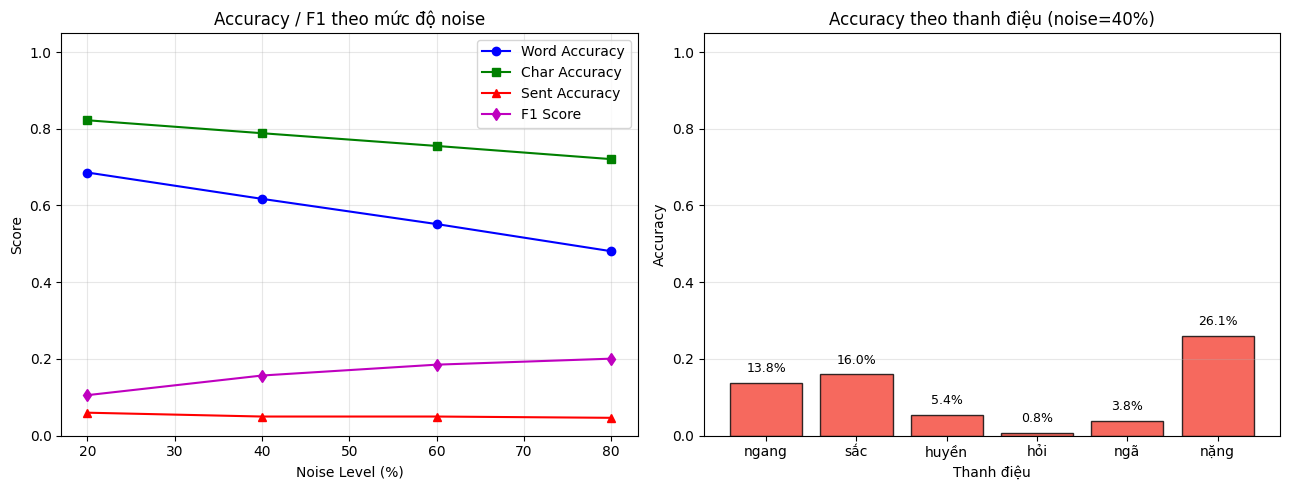


 Đã lưu evaluation_results.png


In [43]:
# ─── Tách test set độc lập (không dùng val_sents) ────────────────────────────
random.seed(SEED)
TEST_SIZE  = 300
test_sents = random.sample(tokenized_sentences[-5000:], TEST_SIZE)  # lấy cuối corpus

TONE_GROUPS = {
    'ngang': {'a','e','i','o','u','y','ă','â','ê','ô','ơ','ư','đ'},
    'sắc'  : {'á','é','í','ó','ú','ý','ắ','ấ','ế','ố','ớ','ứ'},
    'huyền': {'à','è','ì','ò','ù','ỳ','ằ','ầ','ề','ồ','ờ','ừ'},
    'hỏi'  : {'ả','ẻ','ỉ','ỏ','ủ','ỷ','ẳ','ẩ','ể','ổ','ở','ử'},
    'ngã'  : {'ã','ẽ','ĩ','õ','ũ','ỹ','ẵ','ẫ','ễ','ỗ','ỡ','ữ'},
    'nặng' : {'ạ','ẹ','ị','ọ','ụ','ỵ','ặ','ậ','ệ','ộ','ợ','ự'},
}

def get_tone(word: str) -> str:
    """Trả về thanh điệu của từ dựa trên ký tự cuối có dấu."""
    for ch in reversed(word):
        for tone, chars in TONE_GROUPS.items():
            if ch in chars:
                return tone
    return 'ngang'

def char_accuracy(ref: str, hyp: str) -> float:
    """Character-level accuracy giữa 2 chuỗi."""
    if not ref:
        return 1.0
    matches = sum(a == b for a, b in zip(ref, hyp))
    return matches / max(len(ref), len(hyp))

def add_noise(tokens: list, error_rate: float = 0.4) -> list:
    return [
        remove_diacritics(t) if random.random() < error_rate else t
        for t in tokens
    ]


# ─── Đánh giá tổng hợp ────────────────────────────────────────────────────────
print(' Đánh giá tổng hợp trên test set...')
print(f'   Test size: {TEST_SIZE} câu (độc lập với train/val)\n')

NOISE_LEVELS = [0.2, 0.4, 0.6, 0.8]

results_by_noise = {}

for noise in NOISE_LEVELS:
    random.seed(SEED)
    n_word_correct = 0
    n_word_total   = 0
    n_sent_correct = 0
    n_char_correct = 0.0
    n_char_total   = 0

    # Cho F1: TP = từ sai bị sửa đúng, FP = từ đúng bị sửa sai, FN = từ sai không sửa được
    tp = fp = fn = 0

    # Accuracy theo thanh điệu
    tone_correct = collections.defaultdict(int)
    tone_total   = collections.defaultdict(int)

    for sent in tqdm(test_sents, desc=f'  noise={int(noise*100)}%', leave=False):
        noisy         = add_noise(sent, error_rate=noise)
        corrected_str = restore_diacritics(' '.join(noisy))
        corrected     = corrected_str.split()

        min_len = min(len(sent), len(corrected))

        # Word + Char + Tone accuracy
        for j in range(min_len):
            ref, hyp = sent[j], corrected[j]
            n_word_total += 1

            if ref == hyp:
                n_word_correct += 1
            n_char_correct += char_accuracy(ref, hyp)
            n_char_total   += 1

            # Tone accuracy (chỉ tính từ bị noise)
            if noisy[j] != ref:
                tone = get_tone(ref)
                tone_total[tone] += 1
                if ref == hyp:
                    tone_correct[tone] += 1

            # F1 components
            was_wrong   = (noisy[j] != ref)   # từ bị xóa dấu
            now_correct = (hyp == ref)         # model sửa đúng
            if was_wrong and now_correct:
                tp += 1
            elif not was_wrong and hyp != ref:
                fp += 1
            elif was_wrong and not now_correct:
                fn += 1

        # Sentence accuracy
        if ' '.join(sent[:min_len]) == ' '.join(corrected[:min_len]):
            n_sent_correct += 1

    word_acc = n_word_correct / max(n_word_total, 1)
    char_acc = n_char_correct / max(n_char_total, 1)
    sent_acc = n_sent_correct / TEST_SIZE

    precision = tp / max(tp + fp, 1)
    recall    = tp / max(tp + fn, 1)
    f1        = 2 * precision * recall / max(precision + recall, 1e-9)

    results_by_noise[noise] = {
        'word_acc' : word_acc,
        'char_acc' : char_acc,
        'sent_acc' : sent_acc,
        'precision': precision,
        'recall'   : recall,
        'f1'       : f1,
        'tone_acc' : {t: tone_correct[t]/max(tone_total[t],1) for t in tone_total},
    }


# ─── In kết quả theo noise level ─────────────────────────────────────────────
print('\n' + '='*70)
print(f'  {"Noise":>6} | {"Word Acc":>9} | {"Char Acc":>9} | {"Sent Acc":>9} | {"F1":>7} | {"Precision":>9} | {"Recall":>7}')
print('-'*70)
for noise, r in results_by_noise.items():
    print(f'  {int(noise*100):>5}% | {r["word_acc"]:>9.2%} | {r["char_acc"]:>9.2%} | '
          f'{r["sent_acc"]:>9.2%} | {r["f1"]:>7.2%} | {r["precision"]:>9.2%} | {r["recall"]:>7.2%}')
print('='*70)

# ─── Accuracy theo thanh điệu (ở noise=40%) ──────────────────────────────────
print('\n  Accuracy theo thanh điệu (noise=40%):')
tone_r = results_by_noise[0.4]['tone_acc']
for tone in ['ngang','sắc','huyền','hỏi','ngã','nặng']:
    acc = tone_r.get(tone, 0.0)
    bar = '█' * int(acc * 20) + '░' * (20 - int(acc * 20))
    print(f'    {tone:<7}: {bar} {acc:.2%}')

# ─── Đồ thị accuracy vs noise ────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
noise_pcts = [int(n*100) for n in NOISE_LEVELS]

ax1.plot(noise_pcts, [results_by_noise[n]['word_acc'] for n in NOISE_LEVELS],
         'b-o', label='Word Accuracy')
ax1.plot(noise_pcts, [results_by_noise[n]['char_acc'] for n in NOISE_LEVELS],
         'g-s', label='Char Accuracy')
ax1.plot(noise_pcts, [results_by_noise[n]['sent_acc'] for n in NOISE_LEVELS],
         'r-^', label='Sent Accuracy')
ax1.plot(noise_pcts, [results_by_noise[n]['f1']       for n in NOISE_LEVELS],
         'm-d', label='F1 Score')
ax1.set_xlabel('Noise Level (%)'); ax1.set_ylabel('Score')
ax1.set_title('Accuracy / F1 theo mức độ noise')
ax1.legend(); ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1.05)

tones  = [t for t in ['ngang','sắc','huyền','hỏi','ngã','nặng'] if t in tone_r]
t_accs = [tone_r[t] for t in tones]
bars   = ax2.bar(tones, t_accs,
                 color=['#4CAF50' if a >= 0.8 else '#FF9800' if a >= 0.6 else '#F44336'
                        for a in t_accs],
                 alpha=0.8, edgecolor='black')
ax2.set_xlabel('Thanh điệu'); ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy theo thanh điệu (noise=40%)')
ax2.set_ylim(0, 1.05)
ax2.grid(True, alpha=0.3, axis='y')
for bar, acc in zip(bars, t_accs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{acc:.1%}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('evaluation_results.png', dpi=120, bbox_inches='tight')
plt.show()
print('\n Đã lưu evaluation_results.png')
